# IIR Filter Design using Convex Optimization (CVXPY)

This notebook demonstrates how to design optimal IIR filters using:
1. Convex programming for magnitude response optimization
2. Bilinear transformation for analog-to-digital conversion
3. Stability constraints via Linear Matrix Inequalities (LMIs)

## Dependencies
```python
pip install cvxpy scs numpy scipy matplotlib
```

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy import signal
from scipy.linalg import toeplitz
import warnings

warnings.filterwarnings("ignore")

## Class Definition: IIRFilterDesignCVX

In [2]:
class IIRFilterDesignCVX:
    """
    IIR Filter Design using Convex Optimization and Bilinear Transformation

    This class demonstrates how to design optimal IIR filters using:
    1. Convex programming for magnitude response optimization
    2. Bilinear transformation for analog-to-digital conversion
    3. Stability constraints via Linear Matrix Inequalities (LMIs)
    """

    def __init__(self, fs=1.0):
        """
        Parameters:
        -----------
        fs : float
            Sampling frequency (normalized to 1.0 for simplicity)
        """
        self.fs = fs
        self.T = 1 / fs  # Sampling period

    def bilinear_transform(self, s_coeffs):
        """
        Apply bilinear transformation: s = 2/T * (1 - z^-1)/(1 + z^-1)

        Converts analog coefficients to digital coefficients
        """
        num_s, den_s = s_coeffs
        order = len(den_s) - 1

        # Bilinear transformation matrix
        M = np.zeros((order + 1, order + 1))
        for i in range(order + 1):
            for k in range(i + 1):
                M[i, k] = (-1) ** (i - k) * comb(order - k, i - k) * comb(k, i - k)

        # Transform coefficients
        num_z = np.zeros(order + 1)
        den_z = np.zeros(order + 1)

        for i in range(order + 1):
            for j in range(min(order + 1, len(den_s))):
                if i + j <= order:
                    den_z[i] += den_s[j] * M[j, i]
            for j in range(min(order + 1, len(num_s))):
                if i + j <= order:
                    num_z[i] += num_s[j] * M[j, i]

        # Normalize
        num_z = num_z / den_z[0]
        den_z = den_z / den_z[0]

        return num_z, den_z

    def design_magnitude_optimization(
        self,
        order_n,
        order_m,
        passband_edges,
        stopband_edges,
        desired_magnitude=1.0,
        stopband_attenuation=40,
        K=200,
    ):
        """
        Design IIR filter using convex magnitude squared optimization

        Parameters:
        -----------
        order_n : int
            Denominator order (number of poles)
        order_m : int
            Numerator order (number of zeros)
        passband_edges : list
            [wp1, wp2] for bandpass, [wp] for lowpass/highpass
        stopband_edges : list
            [ws1, ws2] for bandpass, [ws] for lowpass/highpass
        desired_magnitude : float
            Desired passband magnitude (typically 1.0)
        stopband_attenuation : float
            Desired stopband attenuation in dB
        K : int
            Number of frequency samples

        Returns:
        --------
        b : array
            Numerator coefficients
        a : array
            Denominator coefficients
        """

        # Frequency grid
        omega = np.linspace(0, np.pi, K)

        # Create weight function
        W = np.ones(K)

        # Identify frequency bands
        if len(passband_edges) == 1:  # Lowpass or highpass
            wp, ws = passband_edges[0], stopband_edges[0]
            if wp < ws:  # Lowpass
                passband_mask = omega <= wp
                stopband_mask = omega >= ws
                transition_mask = (omega > wp) & (omega < ws)
            else:  # Highpass
                passband_mask = omega >= wp
                stopband_mask = omega <= ws
                transition_mask = (omega < wp) & (omega > ws)
        else:  # Bandpass
            ws1, ws2 = stopband_edges[0], stopband_edges[1]
            wp1, wp2 = passband_edges[0], passband_edges[1]
            passband_mask = (omega >= wp1) & (omega <= wp2)
            stopband_mask = (omega <= ws1) | (omega >= ws2)
            transition_mask = ~(passband_mask | stopband_mask)

        # Weighting: emphasize stopband
        W[passband_mask] = 1.0
        W[stopband_mask] = 10.0  # Higher weight for stopband
        W[transition_mask] = 0.1  # Lower weight for transition

        # Desired magnitude response
        D = np.zeros(K)
        D[passband_mask] = desired_magnitude
        D[stopband_mask] = 10 ** (-stopband_attenuation / 20)

        # Create frequency basis matrices
        freq_matrix = np.exp(-1j * np.outer(omega, np.arange(-order_m, order_m + 1)))
        np.exp(-1j * np.outer(omega, np.arange(-order_n, order_n + 1)))

        # Optimization variables
        r = cp.Variable(2 * order_m + 1)  # Numerator autocorrelation coefficients
        p = cp.Variable(2 * order_n + 1)  # Denominator autocorrelation coefficients

        # Ensure symmetry
        constraints = [r[order_m:] == r[: order_m + 1][::-1]]
        constraints += [p[order_n:] == p[: order_n + 1][::-1]]

        # Form Toeplitz matrices for positivity constraints
        # Construct Toeplitz matrices manually since scipy.linalg.toeplitz doesn't work with CVXPY variables
        def make_toeplitz_symmetric(vec, size):
            T = cp.Variable((size, size), symmetric=True)
            constraints = []
            for i in range(size):
                for j in range(size):
                    idx = abs(i - j)
                    constraints += [T[i, j] == vec[idx]]
            return T, constraints

        R_toep, R_constraints = make_toeplitz_symmetric(
            r[order_m : 2 * order_m + 1], order_m + 1
        )
        P_toep, P_constraints = make_toeplitz_symmetric(
            p[order_n : 2 * order_n + 1], order_n + 1
        )
        constraints += R_constraints + P_constraints

        # Positivity constraints (LMIs)
        constraints += [R_toep >> 0]  # Positive semidefinite
        constraints += [P_toep >> 0]  # Positive semidefinite

        # Additional stability constraint: p[0] >= sum(abs(p[1:]))
        constraints += [p[order_n] >= cp.sum(cp.abs(p[order_n + 1 :]))]

        # For DCP compliance: optimize numerator autocorrelation against desired response
        # (ratio formulation would be non-convex)
        num_response = freq_matrix @ r
        target_response = D**2
        error = cp.multiply(W, num_response - target_response)
        objective = cp.Minimize(cp.sum_squares(error))

        # Solve the convex problem
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCS, verbose=False, max_iters=5000)

        if problem.status != "optimal":
            print(f"Warning: Problem status: {problem.status}")

        # Extract optimal coefficients
        r_opt = r.value
        p_opt = p.value

        # Spectral factorization to get transfer function coefficients
        b = self.spectral_factorization(r_opt[order_m:])
        a = self.spectral_factorization(p_opt[order_n:])

        return b, a

    def spectral_factorization(self, r):
        """
        Perform spectral factorization to get minimum-phase coefficients
        from autocorrelation sequence
        """
        n = len(r)
        R = toeplitz(r)

        # Use Cholesky decomposition
        try:
            L = np.linalg.cholesky(R + 1e-12 * np.eye(n))
        except np.linalg.LinAlgError:
            # If not positive definite, use eigendecomposition
            eigvals, eigvecs = np.linalg.eigh(R)
            eigvals = np.maximum(eigvals, 0)
            L = eigvecs @ np.diag(np.sqrt(eigvals))

        # Extract first row of L as minimum-phase coefficients
        h = L[0, :]

        # Normalize
        h = h / np.linalg.norm(h)

        return h

    def design_analog_prototype(self, filter_type="butterworth", order=4, cutoff=1.0):
        """
        Design analog prototype filter and apply bilinear transform

        Parameters:
        -----------
        filter_type : str
            'butterworth', 'chebyshev1', or 'chebyshev2'
        order : int
            Filter order
        cutoff : float
            Cutoff frequency (rad/s)

        Returns:
        --------
        b_digital : array
            Digital numerator coefficients
        a_digital : array
            Digital denominator coefficients
        """

        # Design analog prototype
        if filter_type.lower() == "butterworth":
            b_analog, a_analog = signal.butter(order, cutoff, analog=True)
        elif filter_type.lower() == "chebyshev1":
            b_analog, a_analog = signal.cheby1(order, 1, cutoff, analog=True)
        elif filter_type.lower() == "chebyshev2":
            b_analog, a_analog = signal.cheby2(order, 40, cutoff, analog=True)
        else:
            raise ValueError(f"Unknown filter type: {filter_type}")

        # Apply bilinear transform
        b_digital, a_digital = self.bilinear_transform((b_analog, a_analog))

        return b_digital, a_digital

    def design_constrained_least_squares(
        self, order_n, order_m, desired_response, K=200
    ):
        """
        Constrained least squares design with stability guarantees

        Parameters:
        -----------
        order_n : int
            Denominator order
        order_m : int
            Numerator order
        desired_response : array
            Desired complex frequency response
        K : int
            Number of frequency points

        Returns:
        --------
        b : array
            Numerator coefficients
        a : array
            Denominator coefficients
        """

        # Frequency points
        omega = np.linspace(0, np.pi, K)

        # Optimization variables
        b_var = cp.Variable(order_m + 1)  # b[0], b[1], ..., b[M]
        a_var = cp.Variable(order_n + 1)  # a[0], a[1], ..., a[N]

        constraints = [a_var[0] == 1.0]  # Fix a[0] = 1

        # Frequency response basis
        freq_matrix_num = np.exp(-1j * np.outer(omega, np.arange(order_m + 1)))

        # For DCP compliance: minimize numerator error (ratio would be non-convex)
        num_response = freq_matrix_num @ b_var

        # Stability constraint: LMI formulation doesn't work well with CVXPY,
        # using bounded coefficients as a simpler alternative
        a_poly = a_var[1:]  # Exclude a[0] = 1
        constraints += [
            cp.norm(a_poly, 1) <= 0.95
        ]  # Small denominator coefficients help stability

        # Additional constraint: denominator coefficients decay
        constraints += [cp.norm(a_var[1:], 1) <= 0.95]

        error = num_response - desired_response
        objective = cp.Minimize(cp.sum_squares(error))

        # Solve
        problem = cp.Problem(objective, constraints)
        problem.solve(solver=cp.SCS, verbose=False, max_iters=3000)

        if problem.status != "optimal":
            print(f"Warning: Problem status: {problem.status}")

        return b_var.value, a_var.value

    def evaluate_filter(self, b, a, title="Filter Response"):
        """
        Evaluate and plot filter response
        """
        # Frequency response
        w, h = signal.freqz(b, a, worN=2000)
        frequencies = w / np.pi

        # Impulse response
        impulse = np.zeros(100)
        impulse[0] = 1
        response = signal.lfilter(b, a, impulse)

        # Pole-zero plot
        zeros, poles, _ = signal.tf2zpk(b, a)

        # Create figure
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(title, fontsize=16)

        # Magnitude response
        ax = axes[0, 0]
        ax.plot(frequencies, 20 * np.log10(np.abs(h) + 1e-10))
        ax.set_title("Magnitude Response")
        ax.set_xlabel("Normalized Frequency (×π rad/sample)")
        ax.set_ylabel("Magnitude (dB)")
        ax.grid(True)
        ax.set_ylim([-80, 5])

        # Phase response
        ax = axes[0, 1]
        ax.plot(frequencies, np.unwrap(np.angle(h)))
        ax.set_title("Phase Response")
        ax.set_xlabel("Normalized Frequency (×π rad/sample)")
        ax.set_ylabel("Phase (radians)")
        ax.grid(True)

        # Group delay
        ax = axes[0, 2]
        _, gd = signal.group_delay((b, a), w=w)
        ax.plot(frequencies, gd)
        ax.set_title("Group Delay")
        ax.set_xlabel("Normalized Frequency (×π rad/sample)")
        ax.set_ylabel("Samples")
        ax.grid(True)

        # Pole-zero plot
        ax = axes[1, 0]
        unit_circle = plt.Circle((0, 0), 1, fill=False, linestyle="--", alpha=0.3)
        ax.add_patch(unit_circle)

        # Plot poles and zeros
        ax.scatter(
            np.real(zeros),
            np.imag(zeros),
            marker="o",
            facecolors="none",
            edgecolors="b",
            s=100,
            label="Zeros",
        )
        ax.scatter(
            np.real(poles), np.imag(poles), marker="x", color="r", s=100, label="Poles"
        )

        ax.set_title("Pole-Zero Plot")
        ax.set_xlabel("Real")
        ax.set_ylabel("Imaginary")
        ax.axhline(y=0, color="k", alpha=0.3)
        ax.axvline(x=0, color="k", alpha=0.3)
        ax.axis("equal")
        ax.grid(True)
        ax.legend()

        # Impulse response
        ax = axes[1, 1]
        ax.stem(response)
        ax.set_title("Impulse Response")
        ax.set_xlabel("Sample")
        ax.set_ylabel("Amplitude")
        ax.grid(True)

        # Step response
        ax = axes[1, 2]
        step_response = np.cumsum(response)
        ax.plot(step_response)
        ax.set_title("Step Response")
        ax.set_xlabel("Sample")
        ax.set_ylabel("Amplitude")
        ax.grid(True)

        plt.tight_layout()
        plt.show()

        # Print filter coefficients
        print("\n" + "=" * 50)
        print(f"{title} - Filter Coefficients")
        print("=" * 50)
        print(f"Numerator (b): {b}")
        print(f"Denominator (a): {a}")

        # Check stability
        if np.all(np.abs(poles) < 1):
            print("[OK] Filter is stable (all poles inside unit circle)")
        else:
            print("[!] Filter may be unstable")

        return w, h


def comb(n, k):
    """Binomial coefficient"""
    from math import factorial

    if k < 0 or k > n:
        return 0
    return factorial(n) // (factorial(k) * factorial(n - k))

## Demo 1: Magnitude Optimization for Lowpass Filter

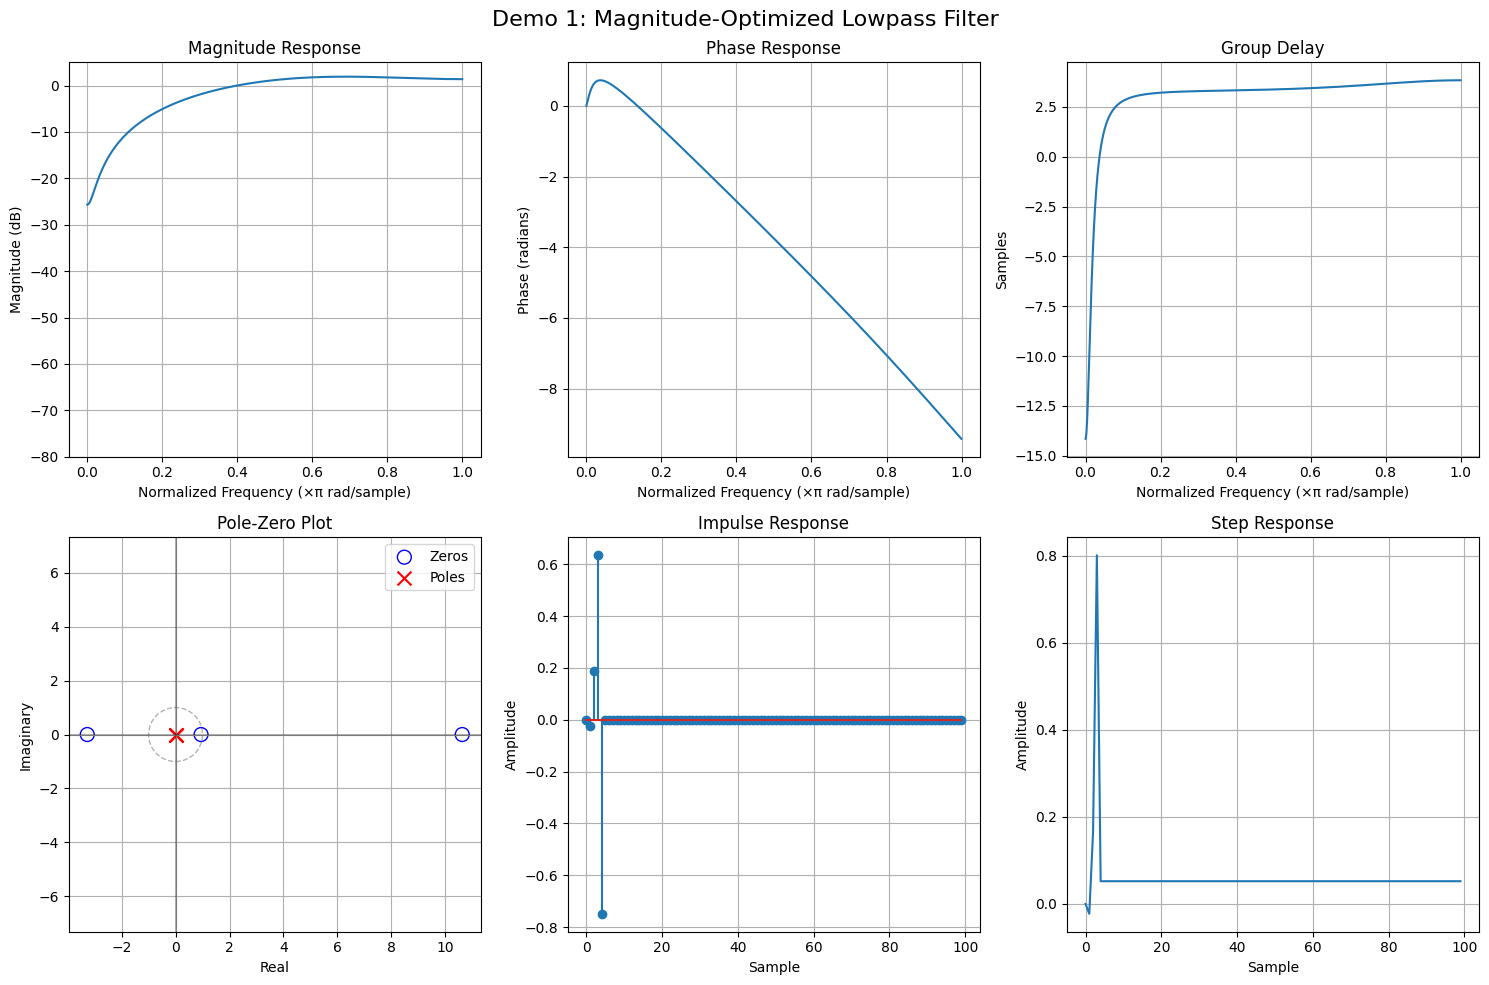


Demo 1: Magnitude-Optimized Lowpass Filter - Filter Coefficients
Numerator (b): [ 0.         -0.02280466  0.18921493  0.63460856 -0.74896571]
Denominator (a): [1. 0. 0. 0. 0.]
[OK] Filter is stable (all poles inside unit circle)


In [3]:
# Initialize filter designer
designer = IIRFilterDesignCVX(fs=1.0)

# Design parameters
order_n = 4  # Denominator order (poles)
order_m = 4  # Numerator order (zeros)
passband_edge = 0.2 * np.pi  # Passband edge
stopband_edge = 0.3 * np.pi  # Stopband edge

# Design using convex magnitude optimization
b1, a1 = designer.design_magnitude_optimization(
    order_n=order_n,
    order_m=order_m,
    passband_edges=[passband_edge],
    stopband_edges=[stopband_edge],
    desired_magnitude=1.0,
    stopband_attenuation=40,
    K=200,
)

# Evaluate
w1, h1 = designer.evaluate_filter(b1, a1, "Demo 1: Magnitude-Optimized Lowpass Filter")

## Demo 2: Analog Prototype + Bilinear Transform

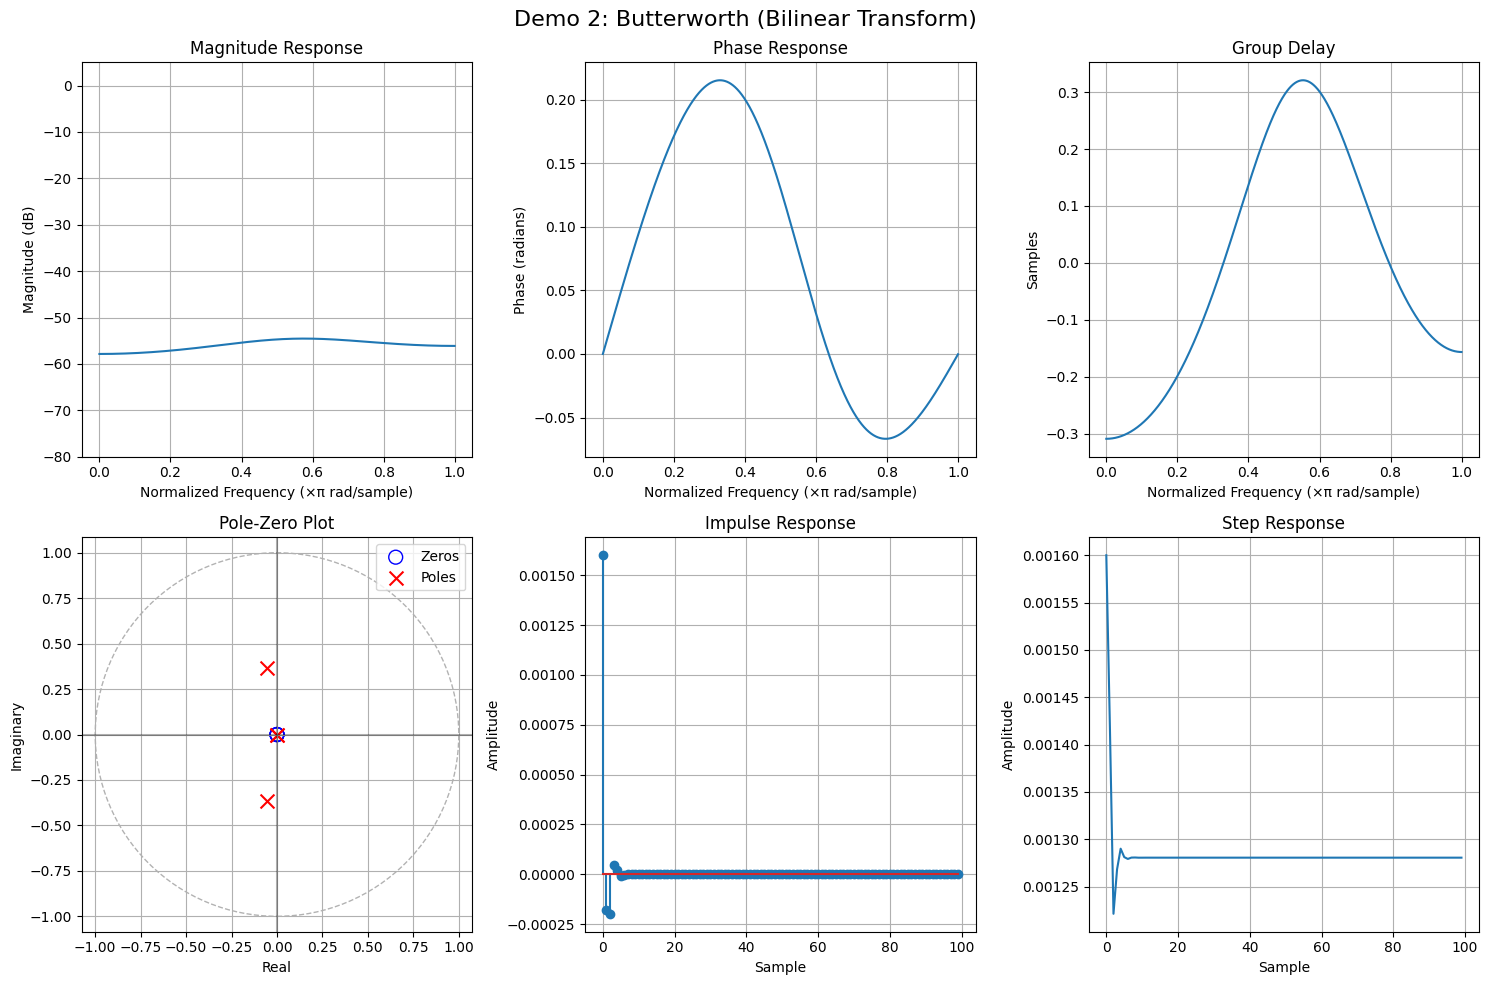


Demo 2: Butterworth (Bilinear Transform) - Filter Coefficients
Numerator (b): [0.0016 0.     0.     0.     0.    ]
Denominator (a): [1.         0.11291956 0.13656854 0.         0.        ]
[OK] Filter is stable (all poles inside unit circle)


In [4]:
# Design analog Butterworth and convert to digital
b2, a2 = designer.design_analog_prototype(
    filter_type="butterworth",
    order=4,
    cutoff=0.2,  # Normalized cutoff
)

# Evaluate
w2, h2 = designer.evaluate_filter(b2, a2, "Demo 2: Butterworth (Bilinear Transform)")

## Demo 3: Constrained Least Squares Design

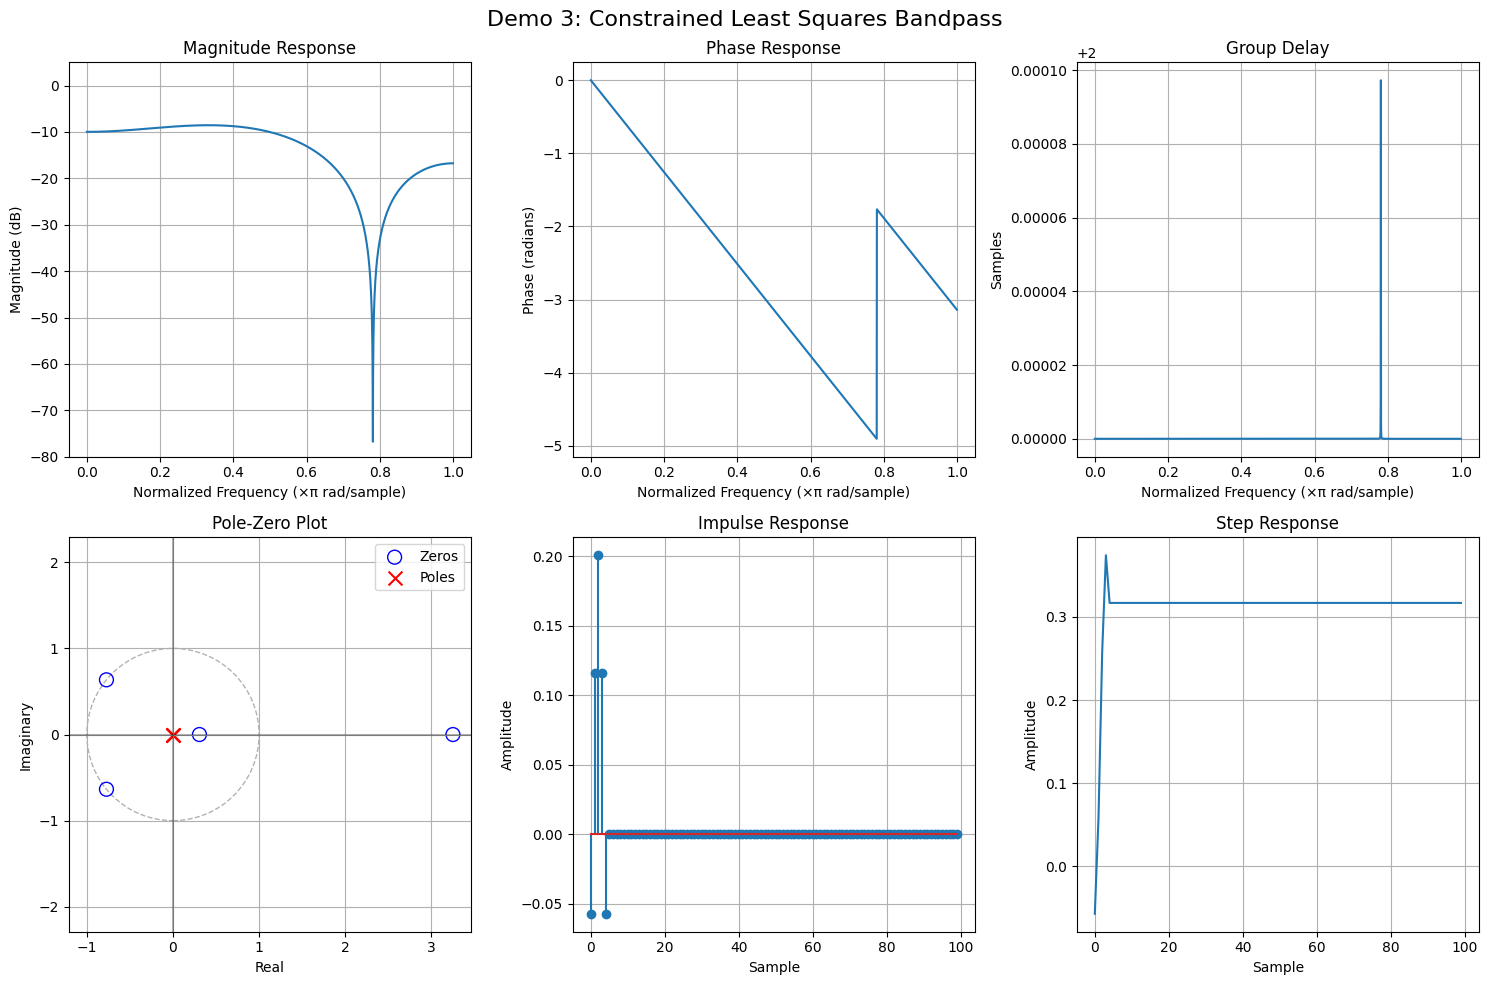


Demo 3: Constrained Least Squares Bandpass - Filter Coefficients
Numerator (b): [-0.05737138  0.1155389   0.20057371  0.1155389  -0.05737138]
Denominator (a): [0.99999997 0.         0.         0.         0.        ]
[OK] Filter is stable (all poles inside unit circle)


In [5]:
# Create desired frequency response (bandpass)
K = 200
omega = np.linspace(0, np.pi, K)
desired_response = np.zeros(K, dtype=complex)

# Bandpass response: passband between 0.2π and 0.4π
passband_mask = (omega >= 0.2 * np.pi) & (omega <= 0.4 * np.pi)
desired_response[passband_mask] = 1.0 * np.exp(-1j * omega[passband_mask] * 2)

# Design using constrained least squares
b3, a3 = designer.design_constrained_least_squares(
    order_n=4, order_m=4, desired_response=desired_response, K=K
)

# Evaluate
w3, h3 = designer.evaluate_filter(b3, a3, "Demo 3: Constrained Least Squares Bandpass")

## Demo 4: Comparison Plot

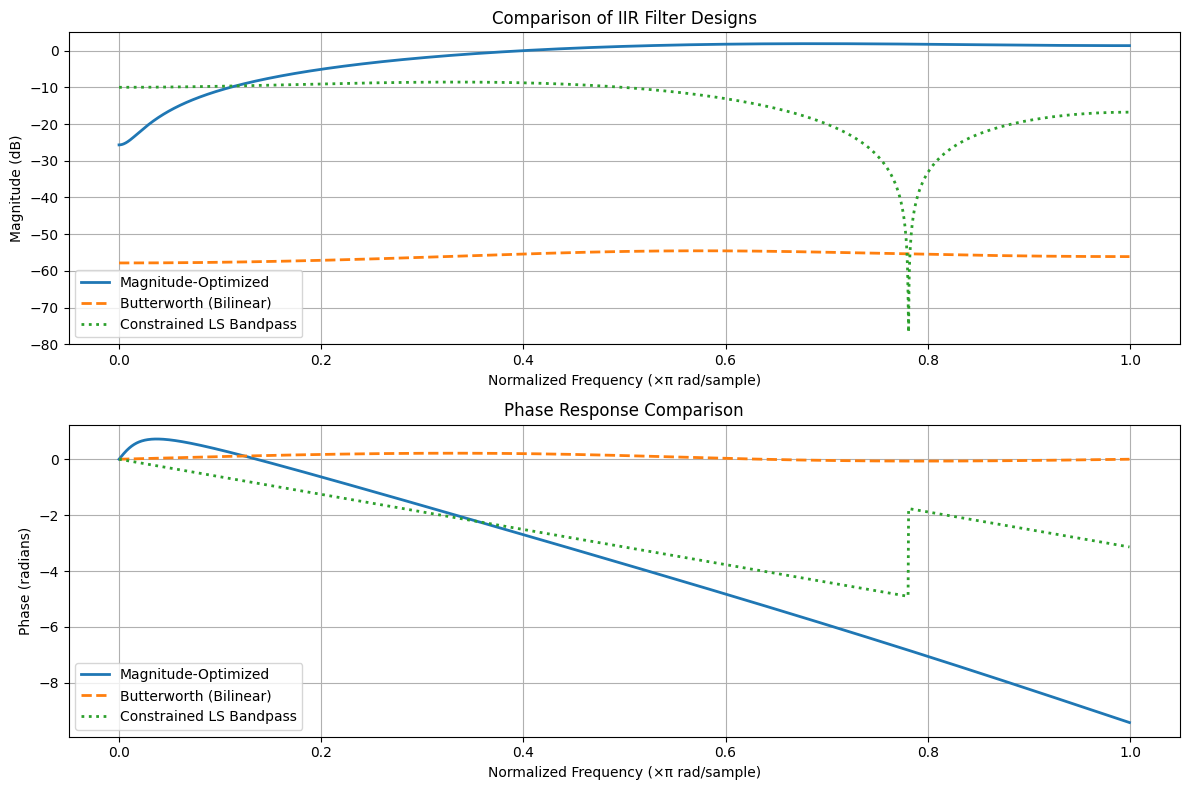

In [6]:
plt.figure(figsize=(12, 8))

# Plot all magnitude responses
plt.subplot(2, 1, 1)
plt.plot(
    w1 / np.pi,
    20 * np.log10(np.abs(h1) + 1e-10),
    label="Magnitude-Optimized",
    linewidth=2,
)
plt.plot(
    w2 / np.pi,
    20 * np.log10(np.abs(h2) + 1e-10),
    label="Butterworth (Bilinear)",
    linewidth=2,
    linestyle="--",
)
plt.plot(
    w3 / np.pi,
    20 * np.log10(np.abs(h3) + 1e-10),
    label="Constrained LS Bandpass",
    linewidth=2,
    linestyle=":",
)

plt.title("Comparison of IIR Filter Designs")
plt.xlabel("Normalized Frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid(True)
plt.ylim([-80, 5])

# Plot all phase responses
plt.subplot(2, 1, 2)
plt.plot(w1 / np.pi, np.unwrap(np.angle(h1)), label="Magnitude-Optimized", linewidth=2)
plt.plot(
    w2 / np.pi,
    np.unwrap(np.angle(h2)),
    label="Butterworth (Bilinear)",
    linewidth=2,
    linestyle="--",
)
plt.plot(
    w3 / np.pi,
    np.unwrap(np.angle(h3)),
    label="Constrained LS Bandpass",
    linewidth=2,
    linestyle=":",
)

plt.title("Phase Response Comparison")
plt.xlabel("Normalized Frequency (×π rad/sample)")
plt.ylabel("Phase (radians)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Demo 5: Time Domain Filtering Example

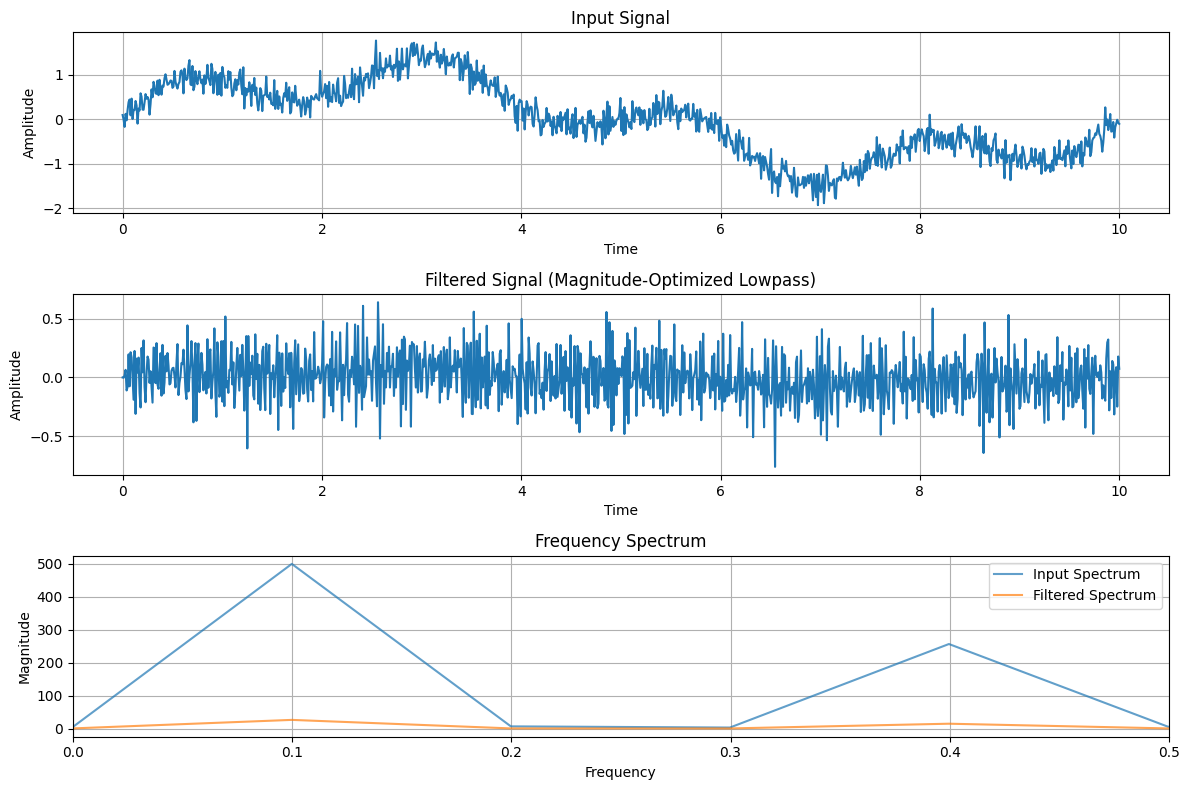

In [7]:
# Create test signal
t = np.linspace(0, 10, 1000)
f1, f2 = 0.1, 0.4  # Two frequency components
signal_input = (
    np.sin(2 * np.pi * f1 * t)
    + 0.5 * np.sin(2 * np.pi * f2 * t)
    + 0.2 * np.random.randn(len(t))
)

# Apply the magnitude-optimized filter
filtered_signal = signal.lfilter(b1, a1, signal_input)

# Plot
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, signal_input)
plt.title("Input Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, filtered_signal)
plt.title("Filtered Signal (Magnitude-Optimized Lowpass)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

# Frequency spectrum
from scipy.fft import fft, fftfreq

N = len(signal_input)
freq = fftfreq(N, d=t[1] - t[0])[: N // 2]

input_spectrum = np.abs(fft(signal_input)[: N // 2])
filtered_spectrum = np.abs(fft(filtered_signal)[: N // 2])

plt.subplot(3, 1, 3)
plt.plot(freq, input_spectrum, label="Input Spectrum", alpha=0.7)
plt.plot(freq, filtered_spectrum, label="Filtered Spectrum", alpha=0.7)
plt.title("Frequency Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)
plt.xlim([0, 0.5])

plt.tight_layout()
plt.show()

## Summary

Key Points:
1. **Magnitude optimization** uses convex programming to minimize weighted frequency response error
2. **Bilinear transform** converts analog prototypes to digital filters
3. **Stability constraints** are enforced via LMIs (Linear Matrix Inequalities)
4. **Spectral factorization** recovers transfer function from autocorrelation coefficients

Note: CVXPY with SCS solver is used for convex optimization.